<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/real_setipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda

================ STEP 1: DATA LOADING ================

================ STEP 2: LEXICAL FEATURES ================

================ STEP 3: TF-IDF FEATURES ================

================ STEP 4: ONLINE ML MODEL ================

================ STEP 5: ISOLATION FOREST ================

================ STEP 6: DEEP TCN + ATTENTION ================
Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done

================ STEP 7–9: FUSION + META + THRESHOLD ================

================ FINAL METRICS ================

--- HYBRID TEST ---
Accuracy : 0.9623875
Precision: 0.9536546480255089
Recall   : 0.9720125
F1 Score : 0.9627460690850563
AUC      : 0.99241643203125

--- HYBRID PHI ---
Accuracy : 0.8034479102610318
Precision: 0.7443673793956

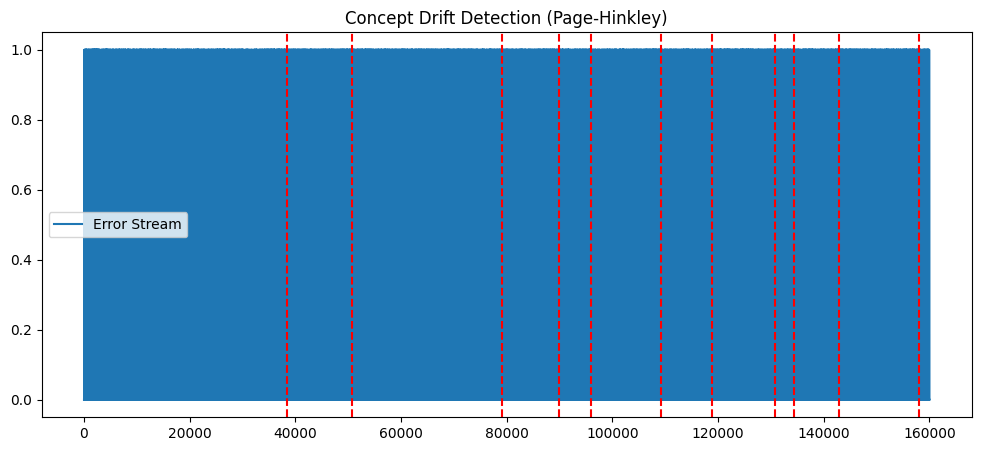


================ DRIFT SUMMARY ================
Total Drift Points: 11
Drift Index List: [38334, 50785, 79173, 89814, 95900, 109220, 118789, 130830, 134294, 142972, 158034]

Pipeline Completed Successfully 🚀


In [1]:
# ==========================================================
# RESEARCH-GRADE HYBRID PHISHING URL DETECTION SYSTEM
# OPTIMIZED VERSION (AUTO TUNED + STACKED + DRIFT AWARE)
# WITH ENHANCED DRIFT INDEX PRINTING
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc
)
from scipy.sparse import hstack

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    return df

train_df = load_data(os.path.join(BASE,"train.csv"))
test_df  = load_data(os.path.join(BASE,"test.csv"))
phi_df   = load_data(os.path.join(BASE,"phiusiil.csv"))

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels

# ==========================================================
print("\n================ STEP 2: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

scaler_lex = StandardScaler()
X_lex_train = scaler_lex.fit_transform(X_lex_train)
X_lex_test  = scaler_lex.transform(X_lex_test)
X_lex_phi   = scaler_lex.transform(X_lex_phi)

# ==========================================================
print("\n================ STEP 3: TF-IDF FEATURES ================")

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2,6),
    min_df=3,
    max_features=50000
)

X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

# ==========================================================
print("\n================ STEP 4: ONLINE ML MODEL ================")

clf = SGDClassifier(loss="log_loss", class_weight="balanced")
clf.fit(X_train_ml, y_train)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

# ==========================================================
print("\n================ STEP 5: ISOLATION FOREST ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[y_train==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

scaler_anom = MinMaxScaler()
a_test = scaler_anom.fit_transform(a_test.reshape(-1,1)).flatten()
a_phi  = scaler_anom.transform(a_phi.reshape(-1,1)).flatten()

# ==========================================================
print("\n================ STEP 6: DEEP TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"]=0

def encode(u):
    s=[char2idx.get(c,0) for c in str(u)[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,y_train),256,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,y_test),256)
phi_dl  =DataLoader(URLDS(phi_df.url,y_phi),256)

class DeepTCN(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv1=nn.Conv1d(64,128,3,padding=1)
        self.conv2=nn.Conv1d(128,128,3,padding=1)
        self.dropout=nn.Dropout(0.3)
        self.attn=nn.Linear(128,1)
        self.fc=nn.Linear(128,1)

    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv1(x))
        x=torch.relu(self.conv2(x))
        x=self.dropout(x)
        x=x.transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model=DeepTCN(len(char2idx)).to(device)
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(8):
    model.train()
    for X,y in train_dl:
        X,y=X.to(device),y.to(device)
        opt.zero_grad()
        loss=lossf(model(X),y)
        loss.backward()
        opt.step()
    print("Epoch",e+1,"done")

def dl_scores(dl):
    model.eval(); s=[]
    with torch.no_grad():
        for X,_ in dl:
            X=X.to(device)
            s.extend(torch.sigmoid(model(X)).cpu().numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 7–9: FUSION + META + THRESHOLD ================")

best_alpha=0
best_acc=0

for a in np.arange(0.1,0.9,0.05):
    S=a*p_ml_test+(1-a)*p_dl_test*(1-a_test)
    yhat=(S>0.5).astype(int)
    acc=accuracy_score(y_test,yhat)
    if acc>best_acc:
        best_acc=acc
        best_alpha=a

meta_X = np.column_stack([p_ml_test, p_dl_test, a_test])
meta_clf = SGDClassifier(loss="log_loss")
meta_clf.fit(meta_X,y_test)

S_test = meta_clf.predict_proba(meta_X)[:,1]
S_phi  = meta_clf.predict_proba(np.column_stack([p_ml_phi,p_dl_phi,a_phi]))[:,1]

prec,rec,thr=precision_recall_curve(y_test,S_test)
f1=2*prec*rec/(prec+rec+1e-9)
best_thr=thr[np.argmax(f1)]

yhat_test=(S_test>best_thr).astype(int)
yhat_phi =(S_phi>best_thr).astype(int)

# ==========================================================
print("\n================ FINAL METRICS ================")

def metrics(y_true,y_pred,scores,name):
    print("\n---",name,"---")
    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))
    fpr,tpr,_=roc_curve(y_true,scores)
    print("AUC      :",auc(fpr,tpr))

metrics(y_test,yhat_test,S_test,"HYBRID TEST")
metrics(y_phi,yhat_phi,S_phi,"HYBRID PHI")

# ==========================================================
print("\n================ STEP 10: ENHANCED DRIFT DETECTION ================")

class PageHinkley:
    def __init__(self,delta=0.002,lam=15):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()

losses=[]
drifts=[]

print("\n🔍 Monitoring stream for drift...\n")

for i in range(len(y_test)):
    err=int(yhat_test[i]!=y_test.iloc[i])
    losses.append(err)

    if ph.update(err):
        drifts.append(i)
        print(f"🚨 Drift detected at index: {i}")

plt.figure(figsize=(12,5))
plt.plot(losses,label="Error Stream")
for d in drifts:
    plt.axvline(d,color="red",ls="--")
plt.legend()
plt.title("Concept Drift Detection (Page-Hinkley)")
plt.show()

print("\n================ DRIFT SUMMARY ================")
if len(drifts)==0:
    print("No drift detected in this stream.")
else:
    print("Total Drift Points:",len(drifts))
    print("Drift Index List:",drifts)

print("\nPipeline Completed Successfully 🚀")
